In [13]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import ast
import seaborn as sns

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [14]:
df_DA_US = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()


In [15]:
df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month

In [16]:
df_DA_US_explode = df_DA_US.explode('job_skills')


In [17]:
df_DA_US_pivot = df_DA_US_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size',fill_value=0)
df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()
df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values().index]
df_DA_US_pivot = df_DA_US_pivot.drop('Total')


In [20]:
DA_totals = df_DA_US.groupby('job_posted_month_no').size()
df_DA_US_percent = df_DA_US_pivot.div(DA_totals/10000, axis=0)
df_DA_US_percent = df_DA_US_percent.reset_index()
df_DA_US_percent['job_posted_month'] = df_DA_US_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_US_percent = df_DA_US_percent.set_index('job_posted_month')
df_DA_US_percent = df_DA_US_percent.drop(columns='job_posted_month_no')
df_DA_US_percent

job_skills,airflow,airtable,alteryx,angular,ansible,apl,arch,asana,asp.net,assembly,...,vmware,vue,watson,webex,windows,wire,word,workfront,yarn,zoom
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,66.079295,0.000000,291.850220,0.000000,5.506608,0.000000,0.000000,5.506608,5.506608,44.052863,...,11.013216,0.000000,0.000000,11.013216,55.066079,0.000000,930.616740,0.000000,0.000000,16.519824
Feb,101.246106,0.000000,264.797508,7.788162,15.576324,0.000000,0.000000,31.152648,15.576324,54.517134,...,0.000000,38.940810,7.788162,7.788162,163.551402,7.788162,996.884735,0.000000,0.000000,15.576324
Mar,80.763583,0.000000,301.027900,7.342144,22.026432,0.000000,0.000000,44.052863,14.684288,29.368576,...,7.342144,14.684288,0.000000,14.684288,102.790015,22.026432,1042.584435,0.000000,0.000000,29.368576
Apr,36.523009,0.000000,416.362308,7.304602,0.000000,0.000000,0.000000,7.304602,0.000000,7.304602,...,14.609204,0.000000,0.000000,7.304602,175.310446,29.218408,1044.558072,7.304602,0.000000,14.609204
May,51.903114,8.650519,302.768166,0.000000,25.951557,0.000000,0.000000,8.650519,17.301038,8.650519,...,0.000000,0.000000,0.000000,8.650519,173.010381,0.000000,795.847751,0.000000,0.000000,8.650519
Jun,82.850041,24.855012,273.405137,8.285004,8.285004,0.000000,16.570008,0.000000,0.000000,33.140017,...,8.285004,0.000000,0.000000,0.000000,124.275062,16.570008,1043.910522,0.000000,0.000000,16.570008
Jul,136.125654,0.000000,345.549738,0.000000,10.471204,0.000000,0.000000,10.471204,0.000000,41.884817,...,0.000000,0.000000,0.000000,0.000000,157.068063,20.942408,1057.591623,0.000000,10.471204,0.000000
Aug,63.649222,14.144272,205.091938,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.009901,...,0.000000,0.000000,0.000000,7.072136,106.082037,7.072136,792.079208,0.000000,0.000000,35.360679
Sep,81.775701,0.000000,221.962617,11.682243,0.000000,11.682243,0.000000,23.364486,0.000000,0.000000,...,23.364486,0.000000,0.000000,0.000000,128.504673,0.000000,759.345794,0.000000,0.000000,23.364486


Text(0.5, 0, '2023')

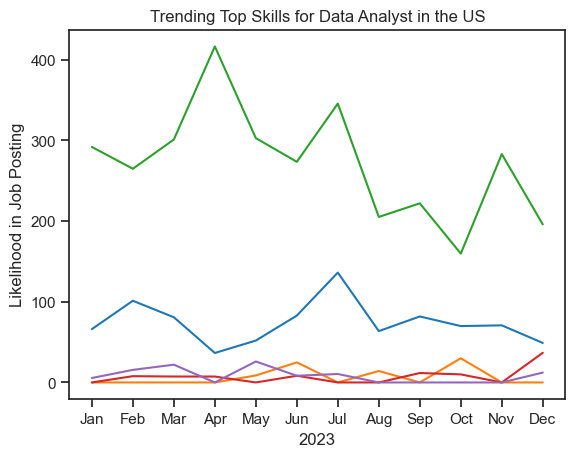

In [33]:
df_plot = df_DA_US_percent.iloc[:,:5]
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
plt.legend().remove()

plt.title('Trending Top Skills for Data Analyst in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')